Benchmark comparing **Gulps** and **Qiskit's XXDecomposer** for compiling circuits to a
discrete RZZ basis set {π/2, π/4, π/6} + U.

Both pipelines are `PassManager` comparisons (no routing/all-to-all connectivity).
We report transpilation wall-clock time and verify output circuit duration is equivalent under our additive cost model where duration is proportional to gate angle.

In [1]:
import warnings
import time
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import lovelyplots
from tqdm.notebook import tqdm
from qiskit.circuit.random import random_circuit

from gulps.comparisons.isa_library.benchmark_xx import (
    build_target,
    build_gulps_pm,
    build_qiskit_pm,
    build_benchmark_circuits,
    circuit_duration,
    count_2q,
)

Sanity Check

In [2]:
target = build_target(4)
qc = random_circuit(4, 3, max_operands=2, seed=0)

for name, pm in [
    ("Qiskit", build_qiskit_pm(target)),
    ("Gulps", build_gulps_pm(target)),
]:
    out = pm.run(qc)
    print(
        f"{name:6s}  {dict(out.count_ops())}  dur={circuit_duration(out) * 1e6:.2f} us"
    )

Qiskit  {'u': 15, 'rzz': 6}  dur=1.95 us
Gulps   {'u': 15, 'rzz': 6}  dur=1.95 us


benchmark circuits

In [3]:
QUBIT_COUNTS = [4, 8, 16, 32, 64]
NUM_RUNS = 3

for n in QUBIT_COUNTS:
    circs = build_benchmark_circuits(n)
    sizes = ", ".join(f"{k}={sum(v.count_ops().values())}g" for k, v in circs.items())
    print(f"  {n:>2}q: {sizes}")

   4q: QFT=12g, EfficientSU2=44g, QV=8g, Random=42g
   8q: QFT=30g, EfficientSU2=88g, QV=32g, Random=168g
  16q: QFT=66g, EfficientSU2=176g, QV=128g, Random=688g
  32q: QFT=138g, EfficientSU2=352g, QV=512g, Random=2741g
  64q: QFT=282g, EfficientSU2=704g, QV=2048g, Random=10963g


In [4]:
results = []
families = list(build_benchmark_circuits(QUBIT_COUNTS[0]).keys())

with tqdm(total=len(QUBIT_COUNTS) * len(families), desc="Benchmarking") as pbar:
    for n in QUBIT_COUNTS:
        circuits = build_benchmark_circuits(n)
        target = build_target(n)
        pm_qk = build_qiskit_pm(target)
        pm_gl = build_gulps_pm(target)

        for name, qc in circuits.items():
            qk_t, gl_t = [], []
            for _ in range(NUM_RUNS):
                t0 = time.perf_counter()
                qk_out = pm_qk.run(qc)
                qk_t.append(time.perf_counter() - t0)

                t0 = time.perf_counter()
                gl_out = pm_gl.run(qc)
                gl_t.append(time.perf_counter() - t0)

            results.append(
                {
                    "circuit": name,
                    "qubits": n,
                    "qiskit_2q": count_2q(qk_out),
                    "gulps_2q": count_2q(gl_out),
                    "qiskit_dur_us": circuit_duration(qk_out) * 1e6,
                    "gulps_dur_us": circuit_duration(gl_out) * 1e6,
                    "qiskit_time_s": sorted(qk_t)[NUM_RUNS // 2],
                    "gulps_time_s": sorted(gl_t)[NUM_RUNS // 2],
                }
            )
            pbar.update(1)

# ── Duration (verify equivalence) ──
print("Circuit Duration (us)")
print(f"{'Circuit':<14} {'Q':>2} {'Qiskit':>9} {'Gulps':>9} {'Diff':>7}")
print("-" * 45)
for r in results:
    d = r["qiskit_dur_us"] - r["gulps_dur_us"]
    print(
        f"{r['circuit']:<14} {r['qubits']:>2} {r['qiskit_dur_us']:>7.1f}us {r['gulps_dur_us']:>7.1f}us {d:>+5.1f}us"
    )

# ── Transpilation time ──
print(f"\nTranspilation Time (median of {NUM_RUNS})")
print(f"{'Circuit':<14} {'Q':>2} {'Qiskit':>9} {'Gulps':>9} {'Speedup':>8}")
print("-" * 47)
for r in results:
    sp = (
        r["qiskit_time_s"] / r["gulps_time_s"]
        if r["gulps_time_s"] > 0
        else float("inf")
    )
    print(
        f"{r['circuit']:<14} {r['qubits']:>2} {r['qiskit_time_s']:>7.3f}s {r['gulps_time_s']:>7.3f}s {sp:>6.1f}x"
    )

Benchmarking:   0%|          | 0/20 [00:00<?, ?it/s]

Circuit Duration (us)
Circuit         Q    Qiskit     Gulps    Diff
---------------------------------------------
QFT             4     6.5us     6.5us  +0.0us
EfficientSU2    4     9.6us     9.4us  +0.2us
QV              4     9.2us     9.2us  +0.0us
Random          4     8.3us     8.3us  +0.0us
QFT             8    16.1us    16.1us  +0.0us
EfficientSU2    8    19.1us    19.0us  +0.2us
QV              8    32.2us    32.2us  +0.0us
Random          8    46.2us    46.3us  -0.0us
QFT            16    35.3us    35.3us  +0.0us
EfficientSU2   16    38.2us    38.1us  +0.2us
QV             16   130.1us   130.0us  +0.1us
Random         16   208.2us   208.3us  -0.1us
QFT            32    73.7us    73.7us  +0.0us
EfficientSU2   32    76.5us    76.3us  +0.2us
QV             32   568.9us   568.7us  +0.1us
Random         32   878.4us   878.6us  -0.2us
QFT            64   150.5us   150.5us  +0.0us
EfficientSU2   64   152.9us   152.7us  +0.2us
QV             64  2328.3us  2327.7us  +0.5us
Random      

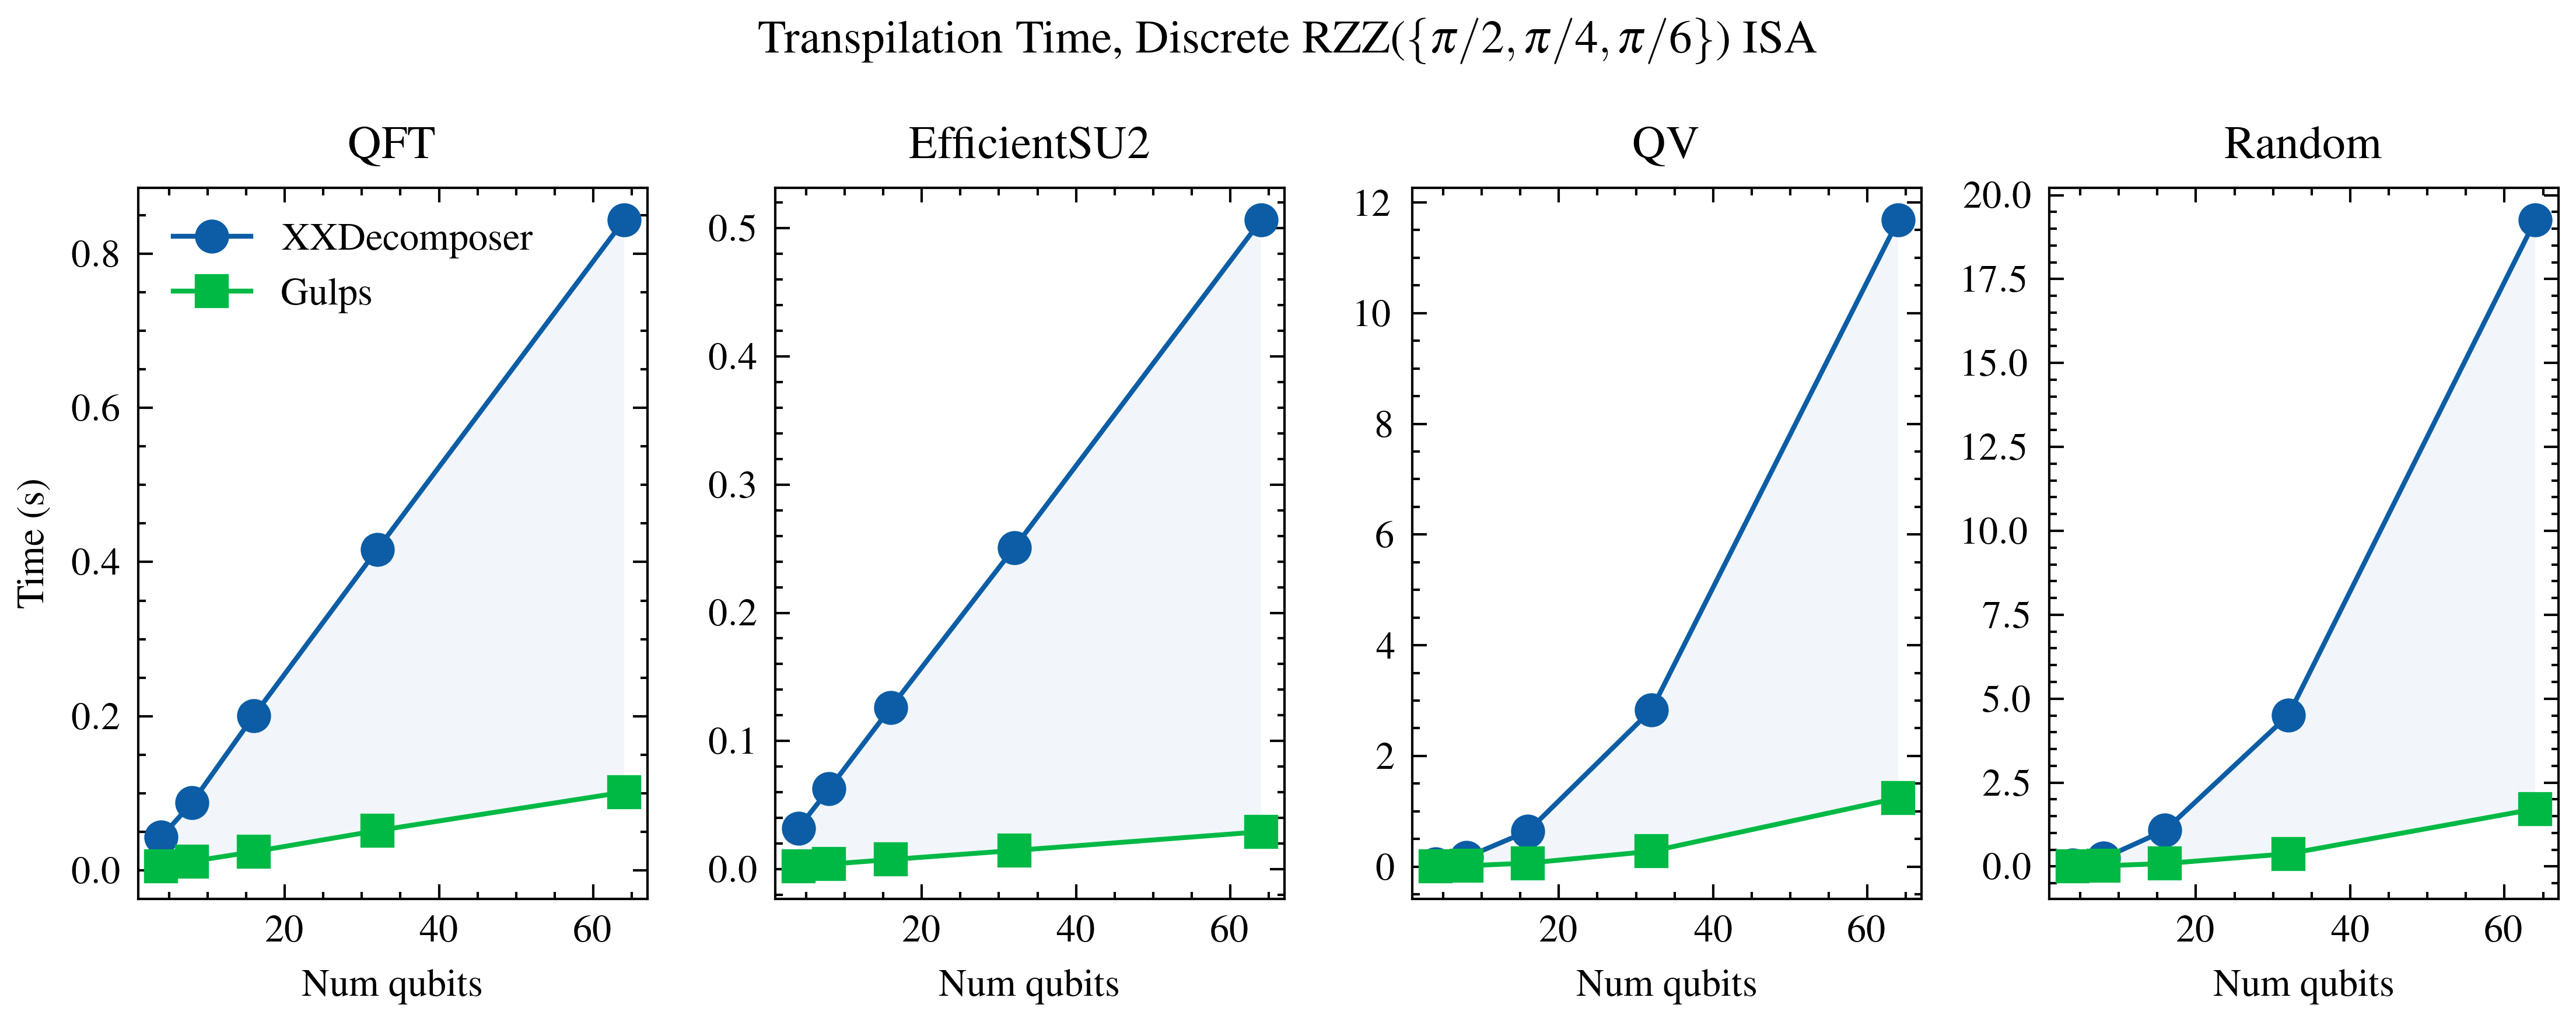

In [5]:
with plt.style.context(["ieee", "science", "no-latex"]):
    fig, axes = plt.subplots(1, 4, figsize=(7.5, 3))

    for ax, family in zip(axes, families):
        fam = [r for r in results if r["circuit"] == family]
        qs = [r["qubits"] for r in fam]
        qk = [r["qiskit_time_s"] for r in fam]
        gl = [r["gulps_time_s"] for r in fam]

        ax.fill_between(qs, gl, qk, alpha=0.05)
        ax.plot(qs, qk, marker="o", label="XXDecomposer")
        ax.plot(qs, gl, marker="s", label="Gulps")
        ax.set_title(family)
        ax.set_xlabel("Num qubits")

    axes[0].set_ylabel("Time (s)")
    axes[0].legend(loc="upper left")
    fig.suptitle(r"Transpilation Time, Discrete RZZ($\{\pi/2, \pi/4, \pi/6\}$) ISA")
    plt.tight_layout()
    plt.show()